### Zadania
 
1. Uruchomić 
   - `naive_multiplication(A,B)`, 
   - `better_multiplication(A,B)` 
   - mnożenie BLAS w Julii (`A*B`) 

    dla coraz większych macierzy kwadratowych i zmierzyć czasy. Narysować wykres zależyności czasu od rozmiaru macierzy wraz z słupkami błędów. Wszystkie trzy metody powinny być na jednym wykresie. **(1pkt)**. Do analizy danych można użyć wybranego narzędzia (Julia, R)
 
 
2. Napisać w języku C:
   - naiwną metodę mnożenia macierzy kwadratowych (wersja 1) 
   - ulepszoną wersję za pomocą zamiany pętli metodę mnożenia macierzy(wersja 2), pamiętając, że w C macierz przechowywana jest wierszami (row major order tzn A11,A12, ..., A1m, A21, A22,...,A2m, ..Anm), inaczej niż w Julii ! 
   - skorzystać z  możliwości BLAS poziom 3 dostępnego w GSL  (przykład uzycia https://www.gnu.org/software/gsl/doc/html/blas.html#examples )
    
    Należy porównywać działanie tych trzech algorytmow bez włączonej opcji optymalizacji kompilatora. Przedstawić wyniki na jednym wykresie tak jak w p.1. (osobno niż p.1). **(1 pkt)**
    
    *(Dla chętnych)* sprawdzić, co się dzieje, jak włączymy optymalizację kompilatora i dodać do wykresu. 
Do analizy danych można użyć wybranego narzędzia (Julia, R)

3.  Użyć aproksymacji odpowiednimi wielomianami, które najlepiej pasują do zależności czasowych każdego z algorytmów. Stopień wielomianu powinien zgadzać się z teoretyczną złożonoscią. Dodać wykresy uzyskanych wielomianów do wcześniejszych wykresów. **(1 pkt)** Do analizy danych można użyć wybranego narzędzia (Julia, R)

4. Pokazać zniwelowanie efektu Rungego  poprzez użycie wsparcia dla wielomianów Czebyszewa w pakiecie Polynomials. Wymagany wykres. **(1 pkt)**

5. Przybliżenie Pade jest często lepsze niż rozwinięcie w szereg Taylora przy aproksymowaniu funkcji, które posiadają osobliwości. Korzystając ze wsparcia dla aproksymacji Pade w pakiecie Polynomials pokazać dowolny przykład (wraz z wykresem), gdzie takie przybliżenie faktycznie jest lepsze. Można odtworzyć wykres z wykładu albo zainspirować się przykładowym artykułem https://www.hindawi.com/journals/ijcm/2014/587430/ **(1 pkt)**


In [1]:
using CSV, Statistics, DataFrames, Plots, LinearAlgebra, Polynomials, TaylorSeries

In [2]:
# Zadanie 1 - porównanie 3 sposobów mnożenia macierzy kwadratowych

In [3]:
# Mnożenie macierzy - wersja naiwna
function naive_multiplication(A,B)
    C = zeros(Float64, size(A,1), size(B,2))
    for i=1:size(A,1)
        for j=1:size(B,2)
            for k=1:size(A,2)
                C[i,j] = C[i,j] + A[i,k]*B[k,j]
            end
        end
    end
    C
end

naive_multiplication (generic function with 1 method)

In [4]:
# Poprawiona funkcja korzytająca z powyższego oraz z faktu, że można zmieniać kolejność operacji dodawania (a co za tym idzie kolejnosc petli).
function better_multiplication(A, B)
    C = zeros(Float64, size(A,1), size(B,2))
    for j=1:size(B,2)
        for k=1:size(A,2)
            for i=1:size(A,1)
                C[i,j] = C[i,j] + A[i,k]*B[k,j]
            end
        end
    end
    C
end

better_multiplication (generic function with 1 method)

In [5]:
# Dane testowe i pomiar czasu

# Rozmiar macierzy kwadratowej 
matrix_size = [10, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 750]

# Mierzenie czasu wykonania funkcji dla każdego rozmiaru macierzy
results = DataFrame(n = Int[], function_name = String[], time_elapsed = Float64[])

for n in matrix_size
    time_for_naive = Float64[]
    time_for_better = Float64[]
    time_for_blas = Float64[]

    A = rand(n, n)
    B = rand(n, n)

    for i in 1:10
        t1 = @elapsed naive_multiplication(A, B)
        push!(time_for_naive, t1)
    
        t2 = @elapsed better_multiplication(A, B)
        push!(time_for_better, t2)
    
        t3 = @elapsed A*B
        push!(time_for_blas, t3)
    end

    for t in time_for_naive
        push!(results, (n, "naive_result", t))
    end
    
    for t in time_for_better
        push!(results, (n, "better_result", t))
    end

    for t in time_for_blas
        push!(results, (n, "BLAS_result", t))
    end
end

In [6]:
# Grupowanie danych według funkcji i rozmiaru macierzy
data_grouped = groupby(results, [:function_name, :n])

# Obliczenie średniej i odchylenia standardowego dla każdej funkcji i rozmiaru macierzy
grouped = combine(data_grouped, :time_elapsed => mean => :mean_time, :time_elapsed => std => :std_time)

# Podział danych na grupy
naive_data = filter(row -> row.function_name == "naive_result", grouped)
better_data = filter(row -> row.function_name == "better_result", grouped)
BLAS_data = filter(row -> row.function_name == "BLAS_result", grouped)

Row,function_name,n,mean_time,std_time
,String,Int64,Float64,Float64
1,BLAS_result,10,0.00290052,0.00916684
2,BLAS_result,50,5.903e-5,2.39677e-5
3,BLAS_result,100,0.00359853,0.00199292
4,BLAS_result,150,0.00266142,0.00112914
5,BLAS_result,200,0.00247642,0.00130816
6,BLAS_result,250,0.00310639,0.000968044
7,BLAS_result,300,0.00454212,0.00126573
8,BLAS_result,350,0.0463294,0.127786
9,BLAS_result,400,0.00812363,0.00357285


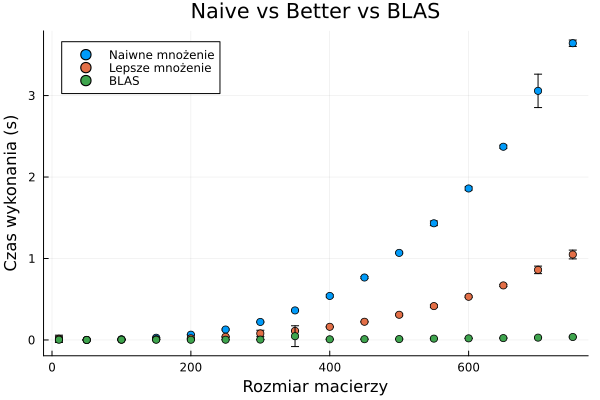

In [7]:
# Porównanie
plot(naive_data.n, naive_data.mean_time, yerr=naive_data.std_time, seriestype=:scatter, 
    label="Naiwne mnożenie", xlabel="Rozmiar macierzy", ylabel="Czas wykonania (s)", title="Naive vs Better vs BLAS", legend=:topleft)

plot!(better_data.n, better_data.mean_time, yerror = better_data.std_time, seriestype = :scatter,
    label = "Lepsze mnożenie")

plot!(BLAS_data.n, BLAS_data.mean_time, yerror = BLAS_data.std_time, seriestype = :scatter,
    label = "BLAS")

In [8]:
# Zadanie 2 - zadanie 1 w języku C

In [ ]:
```c
#include <stdio.h>
#include <stdlib.h>
#include <gsl/gsl_blas.h>
#include <time.h>
#include <string.h>

// Naiwne mnożenie macierzy
void naive_multiplication(double *A, double *B, double *C, int n) {
    for (int i = 0; i < n; i++) {
        for (int j = 0; j < n; j++) {
            C[i*n+j] = 0.0;
        }
    }

    for (int i = 0; i < n; i++) {
        for (int j = 0; j < n; j++) {
            for (int k = 0; k < n; k++) {
                C[i*n+j] += A[i*n+k] * B[k*n+j];
            }
        }
    }
}

// Lepsze mnożenie macierzy
void better_multiplication(double *A, double *B, double *C, int n) {
    for (int i = 0; i < n; i++) {
        for (int j = 0; j < n; j++) {
            C[i*n+j] = 0.0;
        }
    }

    for (int j = 0; j < n; j++) {
        for (int k = 0; k < n; k++) {
            for (int i = 0; i < n; i++) {
                C[i*n+j] += A[i*n+k] * B[k*n+j];
            }
        }
    }
}

// Mnożenie macierzy przy użyciu BLAS
void blas_multiplication(double *A, double *B, double *C, int n) {
    gsl_matrix_view A_view = gsl_matrix_view_array(A, n, n);
    gsl_matrix_view B_view = gsl_matrix_view_array(B, n, n);
    gsl_matrix_view C_view = gsl_matrix_view_array(C, n, n);

    gsl_blas_dgemm(CblasNoTrans, CblasNoTrans, 1.0, &A_view.matrix, &B_view.matrix, 0.0, &C_view.matrix);
}

double measure_avg_time(void (*func)(double*, double*, double*, int), double *A, double *B, double *C, int n) {
    clock_t start, end;
    double total = 0.0;
    for (int i = 0; i < 10; i++) {
        start = clock();
        func(A, B, C, n);
        end = clock();
        total += (double)(end - start) / CLOCKS_PER_SEC;
    }
    return total / 10.0;
}

int main() {
    int matrix_size[] = {10, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 750};
    int num_sizes = sizeof(matrix_size) / sizeof(matrix_size[0]);

    FILE *output = fopen("C_times_opt.csv", "w");

    if (!output) {
        printf("Error opening output file\n");
        return 1;
    }

    fprintf(output, "n,naive,better,bias\n");

    for (int i = 0; i < num_sizes; i++) {
        int n = matrix_size[i];

        double *A = (double *) malloc(n*n * sizeof(double));
        double *B = (double *) malloc(n*n * sizeof(double));
        double *C = (double *) malloc(n*n * sizeof(double));

        if (!A || !B || !C) {
            printf("Error allocating memory\n");
            return 1;
        }

        for (int i = 0; i < n*n; i++) {
            A[i] = rand() / (double) RAND_MAX;
            B[i] = rand() / (double) RAND_MAX;
        }

        double time_naive = measure_avg_time(naive_multiplication, A, B, C, n);
        double time_better = measure_avg_time(better_multiplication, A, B, C, n);
        double time_BLAS = measure_avg_time(blas_multiplication, A, B, C, n);

        printf("n = %d | naive = %.6f s | better = %.6f s | BLAS = %.6f s\n",
               n, time_naive, time_better, time_BLAS);
        fprintf(output, "%d,%.6f,%.6f,%.6f\n", n, time_naive, time_better, time_BLAS);

        free(A);
        free(B);
        free(C);
    }

    fclose(output);
    return 0;
}
```

In [30]:
results = CSV.read("C_times.csv", DataFrame)
results_opt = CSV.read("C_times_opt.csv", DataFrame)

Row,n,naive,better,blas
,Int64,Float64,Float64,Float64
1,10,6.0e-6,5.0e-6,3.0e-6
2,50,0.000667,0.000623,0.00012
3,100,0.003444,0.003354,0.000624
4,150,0.011407,0.011359,0.002758
5,200,0.029197,0.026985,0.004079
6,250,0.058482,0.059047,0.01242
7,300,0.099203,0.109462,0.019794
8,350,0.174181,0.174051,0.030717
9,400,0.256813,0.27084,0.044232


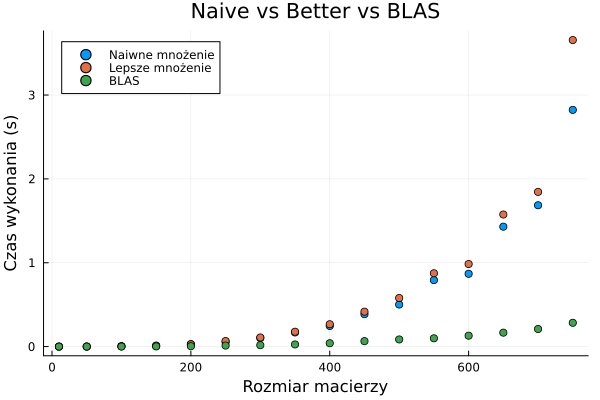

In [31]:
# Porównanie (bez optymalizacji)
plot(results.n, results.naive, seriestype=:scatter, 
    label="Naiwne mnożenie", xlabel="Rozmiar macierzy", ylabel="Czas wykonania (s)", title="Naive vs Better vs BLAS", legend=:topleft)

plot!(results.n, results.better, seriestype = :scatter,
    label = "Lepsze mnożenie")

plot!(results.n, results.blas, seriestype = :scatter,
    label = "BLAS")

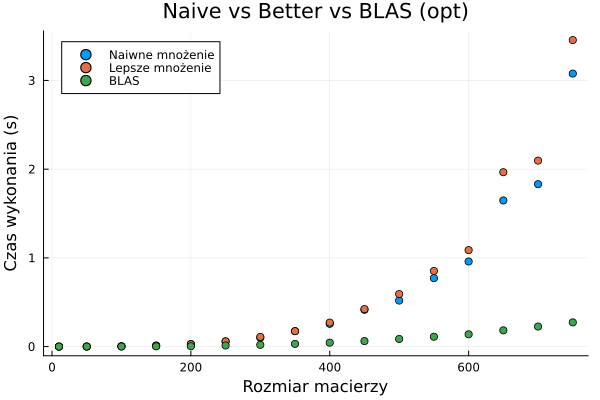

In [32]:
# Porównanie (z optymalizacją)
plot(results_opt.n, results_opt.naive, seriestype=:scatter, 
    label="Naiwne mnożenie", xlabel="Rozmiar macierzy", ylabel="Czas wykonania (s)", title="Naive vs Better vs BLAS (opt)", legend=:topleft)

plot!(results_opt.n, results_opt.better, seriestype = :scatter,
    label = "Lepsze mnożenie")

plot!(results_opt.n, results_opt.blas, seriestype = :scatter,
    label = "BLAS")

In [13]:
# Zadanie 3 - Użyć aproksymacji odpowiednimi wielomianami, które najlepiej pasują do zależności czasowych każdego z algorytmów. 
# Stopień wielomianu powinien zgadzać się z teoretyczną złożonoscią. Dodać wykresy uzyskanych wielomianów do wcześniejszych wykresów. 

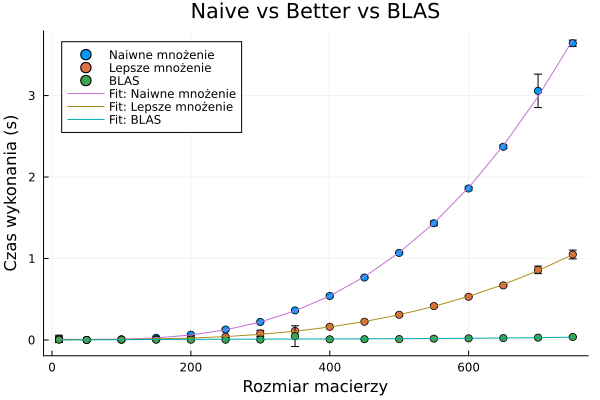

In [36]:
# Wykres z zadania 1 
plot(naive_data.n, naive_data.mean_time, yerr=naive_data.std_time, seriestype=:scatter, 
    label="Naiwne mnożenie", xlabel="Rozmiar macierzy", ylabel="Czas wykonania (s)", title="Naive vs Better vs BLAS", legend=:topleft)

plot!(better_data.n, better_data.mean_time, yerror = better_data.std_time, seriestype = :scatter,
    label = "Lepsze mnożenie")

plot!(BLAS_data.n, BLAS_data.mean_time, yerror = BLAS_data.std_time, seriestype = :scatter,
    label = "BLAS")


# Dopasowanie i rysowanie wielomianów (teoretyczna złożoność algorytmów to O(n^3))
poly_naive = fit(Polynomial, naive_data.n, naive_data.mean_time, 3)
plot!(naive_data.n, poly_naive.(naive_data.n), label="Fit: Naiwne mnożenie") # poly_naive.(naive_data.n) - obliczanie wartości dopasowanego wielomianu

poly_better = fit(Polynomial, better_data.n, better_data.mean_time, 3)
plot!(better_data.n, poly_better.(better_data.n), label="Fit: Lepsze mnożenie")

poly_blas = fit(Polynomial, BLAS_data.n, BLAS_data.mean_time, 3)
plot!(BLAS_data.n, poly_blas.(BLAS_data.n), label="Fit: BLAS")

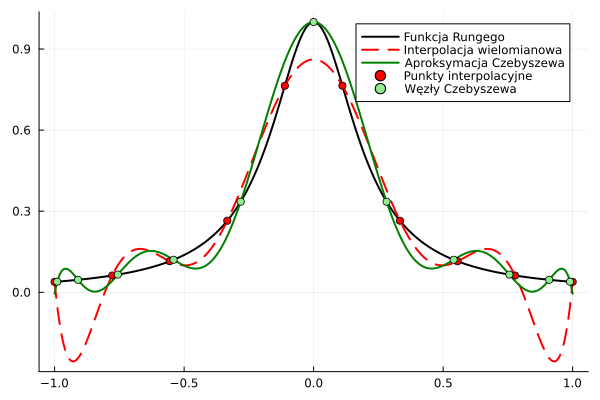

In [50]:
# Zadanie 4 - Pokazać zniwelowanie efektu Rungego poprzez użycie wsparcia dla wielomianów Czebyszewa w pakiecie Polynomials. Wymagany wykres. 

# Funkcja Rungego
runge(x) = 1 / (1 + 25*x^2)

# Przedział i punkty interpolacji
a, b = -1, 1
n = 10
xs = range(a, b, length=n)
ys = runge.(xs)

# Punkty do rysowania wykresu
x_plot = range(a, b, length=500)

# Interpolacja wielomianowa (efekt Rungego)
poly = fit(xs, ys, n-1)  # Dopasowanie wielomianu
y_poly = poly.(x_plot)

# Aproksymacja Czebyszewa
baza = [0,0,0,0,0,0,0,0,0,0,0,1]  # Wielomian Czebyszewa
czebyszew = ChebyshevT(baza)
czebyszew_nodes = Polynomials.roots(czebyszew)  # Węzły Czebyszewa w [-1, 1]
ys2 = runge.(czebyszew_nodes)  # Wartości funkcji Rungego w węzłach
poly_approx_2 = fit(czebyszew_nodes, ys2, 10)

# Aproksymacja Czebyszewa na siatce
ysf2 = poly_approx_2.(x_plot)

# Wykres
plot(x_plot, runge.(x_plot), label="Funkcja Rungego", lw=2, color=:black)
plot!(x_plot, y_poly, label="Interpolacja wielomianowa", lw=2, ls=:dash, color=:red)
plot!(x_plot, ysf2, label="Aproksymacja Czebyszewa", lw=2, color=:green)
scatter!(xs, ys, label="Punkty interpolacyjne", color=:red)
scatter!(czebyszew_nodes, ys2, label="Węzły Czebyszewa", color=:lightgreen)

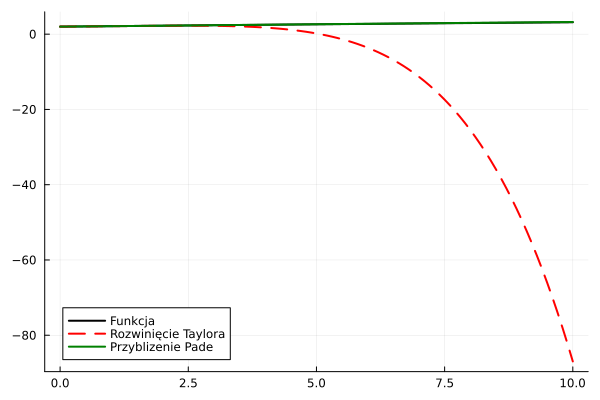

In [55]:
# Zadanie 5 - Przybliżenie Pade jest często lepsze niż rozwinięcie w szereg Taylora przy aproksymowaniu funkcji, które posiadają osobliwości. 
# Korzystając ze wsparcia dla aproksymacji Pade w pakiecie Polynomials pokazać dowolny przykład (wraz z wykresem), gdzie takie przybliżenie faktycznie jest lepsze.
function F(x) 
    (7+((1+x)^(4/3)))^(1/3)
end

# Definiujemy, ile pierwszych wyrazów szeregu Taylora nas interesuje
t = Taylor1(Float64, 5)

#Rozwinięcie Taylora 
F_taylor = F(t)

# Z przybliżenia Taylora tworzę wielomian zrozumiały dla pakietu Polynomials (typ Polynomial)
F_t_pol = Polynomial(F_taylor.coeffs)
F_pade = Polynomials.PolyCompat.PadeApproximation.Pade(F_t_pol, 2, 2)

xsf = 0:0.1:10
y1 = [F(x) for x in xsf]
y2 = [F_t_pol(x) for x in xsf]
y3 = [F_pade(x) for x in xsf]

# Wykres
plot(xsf, y1, label="Funkcja", lw=2, color=:black)
plot!(xsf, y2, label="Rozwinięcie Taylora", lw=2, ls=:dash, color=:red)
plot!(xsf, y3, label="Przyblizenie Pade", lw=2, color=:green)